In [1]:
from google.colab import drive
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
import os
import time
import copy

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Set Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Mounted at /content/drive
Running on: cuda:0


In [10]:
import os
import shutil
import zipfile
import random

# 1. Unzip
zip_path = "/content/drive/MyDrive/plant_training/plant_dataset_clean.zip" # Verify this path
extract_path = "/content/dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Unzip complete.")

# 2. Re-create Validation Split (with the mirror logic for single images)
train_dir = '/content/dataset/train'
val_dir = '/content/dataset/val'

if not os.path.exists(val_dir):
    os.makedirs(val_dir, exist_ok=True)
    for cls in os.listdir(train_dir):
        src_path = os.path.join(train_dir, cls)
        if os.path.isdir(src_path):
            dst_path = os.path.join(val_dir, cls)
            os.makedirs(dst_path, exist_ok=True)
            images = os.listdir(src_path)
            random.shuffle(images)
            if len(images) <= 1:
                for img in images:
                    shutil.copy(os.path.join(src_path, img), os.path.join(dst_path, img))
            else:
                val_count = max(1, int(len(images) * 0.2))
                for i in range(val_count):
                    shutil.move(os.path.join(src_path, images[i]), os.path.join(dst_path, images[i]))
    print("Validation split recreated successfully.")

# 3. Define class_names
class_names = sorted(os.listdir(val_dir))
print(f"Total classes found: {len(class_names)}")

Unzip complete.
Validation split recreated successfully.
Total classes found: 28


In [11]:
# --- Load ResNet-18 ---
resnet = models.resnet18()
num_ftrs_res = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs_res, 28)
resnet.load_state_dict(torch.load('/content/drive/MyDrive/plant_disease_resnet18_v1.pth'))
resnet = resnet.to(device).eval()

# --- Load MobileNetV2 ---
mobilenet = models.mobilenet_v2()
num_ftrs_mob = mobilenet.classifier[1].in_features
mobilenet.classifier[1] = nn.Linear(num_ftrs_mob, 28)
mobilenet.load_state_dict(torch.load('/content/drive/MyDrive/plant_disease_mobilenet_v1.pth'))
mobilenet = mobilenet.to(device).eval()

print("Both models loaded and set to evaluation mode.")

Both models loaded and set to evaluation mode.


In [12]:
def get_latency(model, name):
    # Create a dummy image (batch size 1, 3 channels, 224x224)
    dummy_input = torch.randn(1, 3, 224, 224).to(device)

    # Warm up (standard practice for GPU)
    for _ in range(10):
        _ = model(dummy_input)

    # Measure
    start_time = time.time()
    iterations = 100
    with torch.no_grad():
        for _ in range(iterations):
            _ = model(dummy_input)
    end_time = time.time()

    avg_ms = ((end_time - start_time) / iterations) * 1000
    print(f"{name} Average Latency: {avg_ms:.2f} ms")
    return avg_ms

res_latency = get_latency(resnet, "ResNet-18")
mob_latency = get_latency(mobilenet, "MobileNetV2")

ResNet-18 Average Latency: 3.05 ms
MobileNetV2 Average Latency: 5.02 ms


In [13]:
res_size = os.path.getsize('/content/drive/MyDrive/plant_disease_resnet18_v1.pth') / (1024 * 1024)
mob_size = os.path.getsize('/content/drive/MyDrive/plant_disease_mobilenet_v1.pth') / (1024 * 1024)

print(f"ResNet-18 File Size: {res_size:.2f} MB")
print(f"MobileNetV2 File Size: {mob_size:.2f} MB")
print(f"\nMobileNetV2 is {res_size/mob_size:.1f}x smaller than ResNet-18.")

ResNet-18 File Size: 42.77 MB
MobileNetV2 File Size: 8.86 MB

MobileNetV2 is 4.8x smaller than ResNet-18.


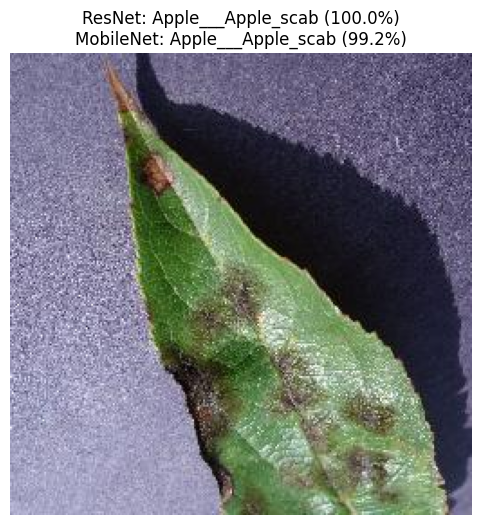

In [15]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_compare(img_path):
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    img = Image.open(img_path)
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        res_out = resnet(input_tensor)
        mob_out = mobilenet(input_tensor)

        res_prob = torch.nn.functional.softmax(res_out, dim=1)
        mob_prob = torch.nn.functional.softmax(mob_out, dim=1)

        res_conf, res_pred = torch.max(res_prob, 1)
        mob_conf, mob_pred = torch.max(mob_prob, 1)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"ResNet: {class_names[res_pred.item()]} ({100*res_conf.item():.1f}%)\n"
              f"MobileNet: {class_names[mob_pred.item()]} ({100*mob_conf.item():.1f}%)")
    plt.axis('off')
    plt.show()

# Pick a test image
random_class = class_names[0]
test_image = os.path.join(val_dir, random_class, os.listdir(os.path.join(val_dir, random_class))[0])
predict_compare(test_image)